In [19]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

import importlib
import attack.reconstruction_algorithms

importlib.reload(attack.reconstruction_algorithms)
from attack.reconstruction_algorithms import *

import random
import numpy as np


import torch
import torch.nn as nn
from torchvision.models import resnet18
from torch.utils.data import random_split, DataLoader, Subset

import torch.optim as optim
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
from pathlib import Path
device = 'cuda'


## Ignore

In [3]:
WORKING_DIRECTORY = Path().cwd
DATA_PATH  = Path('/vol/bitbucket/vb524/safe-unlearning/src/attacks/DGL/data')

ORIGINAL_MODEL = Path('/vol/bitbucket/vb524/safe-unlearning/src/artifacts/models')
UNLEARNED_MODELS = Path('/vol/bitbucket/vb524/safe-unlearning/src/artifacts/unlearned')

In [4]:
WORKING_DIRECTORY = Path('/vol/bitbucket/vb524/sandbox-machine-unlearning/src/sandbox/reconstruction/CIFAR-10/data')



# Store checkpoints
# Path(WORKING_DIRECTORY / "checkpoints").mkdir(parents=True, exist_ok=True)


# Download data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# DATA_PATH = Path(WORKING_DIRECTORY / "/CIFAR-10/data")
train_data = datasets.CIFAR10(DATA_PATH, train = True, download=False, transform = transform)  

# Split
train_size = int(0.8 * len(train_data))
val_size = int(len(train_data) - train_size)

torch.manual_seed(42)

print(f"Training data size {train_size}")
print(f"Validation data size {val_size}")

train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

print(f"Train indices: {train_dataset.indices if hasattr(train_dataset, 'indices') else list(range(train_size))}")
print(f"Val indices: {val_dataset.indices if hasattr(val_dataset, 'indices') else list(range(train_size, len(train_data)))}")


# Dataloader
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)

Training data size 40000
Validation data size 10000
Train indices: [37542, 44491, 216, 43688, 41558, 32245, 27206, 10863, 2190, 31849, 25408, 33504, 27102, 21934, 40181, 47682, 45747, 17004, 43777, 7433, 45129, 37684, 14817, 38215, 30883, 19763, 14041, 46578, 19871, 39339, 39292, 8205, 47307, 15337, 45371, 20844, 26455, 25747, 21000, 49417, 42186, 49238, 25283, 78, 6899, 15568, 11143, 35952, 37965, 33436, 30770, 9583, 35210, 4856, 8020, 44859, 4191, 19421, 34688, 29312, 20326, 17740, 4894, 20621, 2614, 46726, 19045, 5668, 6159, 47718, 7907, 5294, 42872, 24855, 20370, 21209, 32223, 43179, 44262, 38506, 40214, 16895, 12328, 45173, 46138, 13520, 30459, 20165, 11227, 43731, 42697, 17911, 6857, 33366, 32393, 2860, 19849, 43759, 3139, 6468, 29670, 7952, 25577, 16817, 27801, 28896, 19279, 5004, 19713, 33819, 49625, 2477, 25719, 37877, 13626, 23084, 1540, 35115, 38527, 48710, 22399, 1907, 35869, 26348, 49760, 43079, 14963, 46994, 1499, 36242, 38017, 21469, 17152, 28914, 18402, 37833, 15968, 42

In [9]:
criterion = nn.CrossEntropyLoss()
num_epochs = 15

model = resnet18()
model.fc = nn.Linear(512, 10)
model.to(device)
optimiser = optim.SGD(model.parameters(), lr = 0.01)

for epoch in range(num_epochs):
    model.train()
    train_loss, correct = 0., 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimiser.zero_grad()
        pred = model(images)
        loss = criterion(pred, labels)
        loss.backward()
        optimiser.step()
        train_loss += loss.item()

        pred = pred.argmax(dim=1)  
        correct += (pred == labels).sum().item()  # Count correct predictions
        total += labels.size(0)  
    
    train_accuracy = 100 * correct / total

    model.eval()
    eval_loss, correct = 0., 0
    total = 0
    with torch.no_grad(): 
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            pred = model(images)
            loss = criterion(pred, labels)
            eval_loss += loss.item()

            pred = pred.argmax(dim=1) 
            correct += (pred == labels).sum().item()  # Count correct predictions
            total += labels.size(0)  
    
    eval_accuracy = 100 * correct / total

    train_loss /= len(train_loader)
    eval_loss /= len(val_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {eval_loss:.4f}, Train Accuracy {train_accuracy}, Val Accuracy {eval_accuracy}")


Epoch 1/15, Train Loss: 1.6080, Val Loss: 1.3358, Train Accuracy 41.625, Val Accuracy 51.25
Epoch 2/15, Train Loss: 1.2515, Val Loss: 1.1342, Train Accuracy 55.205, Val Accuracy 59.19
Epoch 3/15, Train Loss: 1.0524, Val Loss: 1.0463, Train Accuracy 62.8625, Val Accuracy 62.27
Epoch 4/15, Train Loss: 0.8949, Val Loss: 0.9765, Train Accuracy 68.1125, Val Accuracy 65.37
Epoch 5/15, Train Loss: 0.7645, Val Loss: 1.0108, Train Accuracy 72.8575, Val Accuracy 65.14
Epoch 6/15, Train Loss: 0.6513, Val Loss: 0.9993, Train Accuracy 76.8125, Val Accuracy 65.94
Epoch 7/15, Train Loss: 0.5474, Val Loss: 1.0160, Train Accuracy 80.61, Val Accuracy 67.25
Epoch 8/15, Train Loss: 0.4585, Val Loss: 1.0407, Train Accuracy 83.765, Val Accuracy 67.61
Epoch 9/15, Train Loss: 0.3870, Val Loss: 1.0777, Train Accuracy 86.1225, Val Accuracy 67.9
Epoch 10/15, Train Loss: 0.3198, Val Loss: 1.1319, Train Accuracy 88.68, Val Accuracy 68.48
Epoch 11/15, Train Loss: 0.2637, Val Loss: 1.1776, Train Accuracy 90.7025, Va

In [16]:
torch.save(model.state_dict(), f"{ORIGINAL_MODEL}/exp1_original.pth")

Training data size 40000
Validation data size 10000
Train indices: [37542, 44491, 216, 43688, 41558, 32245, 27206, 10863, 2190, 31849, 25408, 33504, 27102, 21934, 40181, 47682, 45747, 17004, 43777, 7433, 45129, 37684, 14817, 38215, 30883, 19763, 14041, 46578, 19871, 39339, 39292, 8205, 47307, 15337, 45371, 20844, 26455, 25747, 21000, 49417, 42186, 49238, 25283, 78, 6899, 15568, 11143, 35952, 37965, 33436, 30770, 9583, 35210, 4856, 8020, 44859, 4191, 19421, 34688, 29312, 20326, 17740, 4894, 20621, 2614, 46726, 19045, 5668, 6159, 47718, 7907, 5294, 42872, 24855, 20370, 21209, 32223, 43179, 44262, 38506, 40214, 16895, 12328, 45173, 46138, 13520, 30459, 20165, 11227, 43731, 42697, 17911, 6857, 33366, 32393, 2860, 19849, 43759, 3139, 6468, 29670, 7952, 25577, 16817, 27801, 28896, 19279, 5004, 19713, 33819, 49625, 2477, 25719, 37877, 13626, 23084, 1540, 35115, 38527, 48710, 22399, 1907, 35869, 26348, 49760, 43079, 14963, 46994, 1499, 36242, 38017, 21469, 17152, 28914, 18402, 37833, 15968, 42

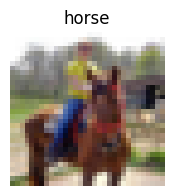

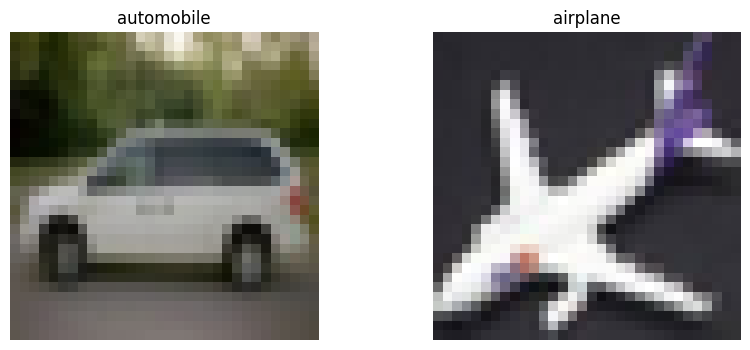

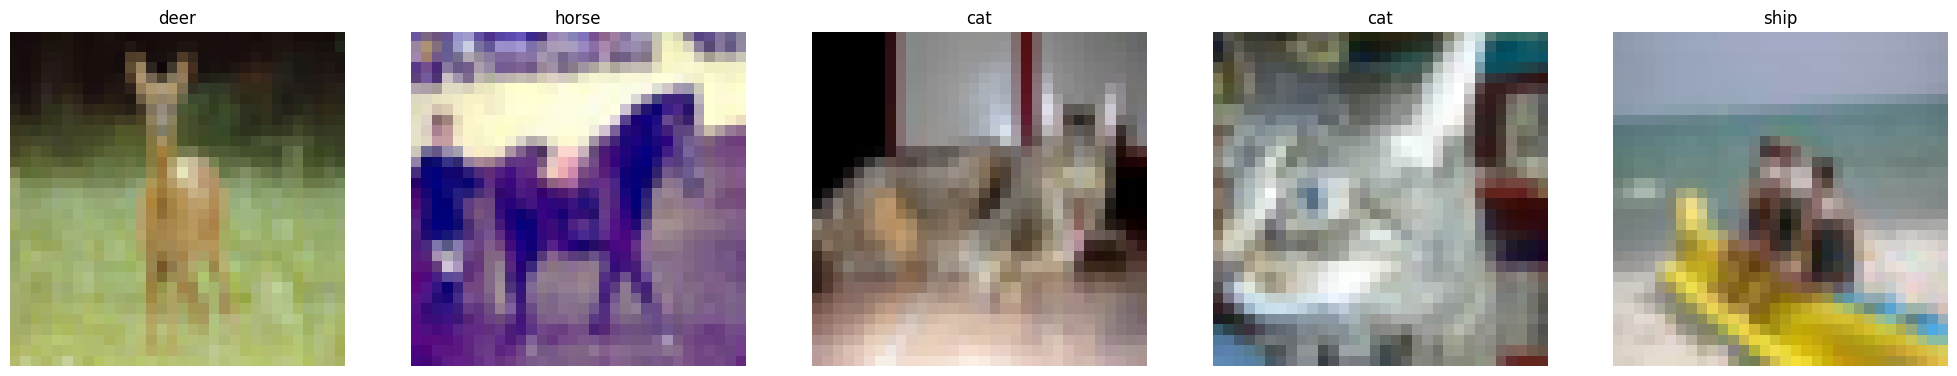

In [5]:
torch.manual_seed(42)

train_size = int(0.8 * len(train_data))
val_size = int(len(train_data) - train_size)


print(f"Training data size {train_size}")
print(f"Validation data size {val_size}")

train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

print(f"Train indices: {train_dataset.indices if hasattr(train_dataset, 'indices') else list(range(train_size))}")
print(f"Val indices: {val_dataset.indices if hasattr(val_dataset, 'indices') else list(range(train_size, len(train_data)))}")

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

train_indices = list(range(len(train_dataset))) 

def get_forget_dataset(forget_k):
    
    forget_indices = random.sample(train_indices, k=min(forget_k, len(train_indices)))
    retain_indices = list(set(train_indices) - set(forget_indices))

    assert all(i < len(train_dataset.dataset) for i in forget_indices)

    forget_dataset = Subset(train_dataset, forget_indices)
    retain_dataset = Subset(train_dataset, retain_indices)

    batch_size = min(forget_k, 32, len(forget_dataset))
    forget_dataloader = DataLoader(forget_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    retain_dataloader = DataLoader(retain_dataset, batch_size=32, shuffle=False)

    return forget_dataloader, retain_dataloader

forget1_dataloader, retain1_dataloader = get_forget_dataset(1)
forget2_dataloader, retain2_dataloader = get_forget_dataset(2)
forget5_dataloader, retain5_dataloader = get_forget_dataset(5)

forget64_dataloader, retain64_dataloader = get_forget_dataset(32)

def denormalize(img):
    mean = torch.tensor([0.5, 0.5,0.5]).view(3,1,1)  # CIFAR-100 mean
    std = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)   # CIFAR-100 std
    img = img * std + mean
    return img.clamp(0,1)



def visualise(loader, forget_size):
    images, labels = next(iter(loader))
    images = denormalize(images)

    images = images[:forget_size]  
    labels = labels[:forget_size]

    # Convert images to (H, W, C) format for plotting
    images = images.permute(0, 2, 3, 1).numpy()  

    class_names = train_data.classes  

    # Plot images
    if forget_size == 1:
        fig, ax = plt.subplots(figsize=(5, 2))  
        ax.imshow(images[0])  
        ax.set_title(class_names[labels[0].item()])  
        ax.axis('off')  
        plt.show()  # Display the plot

    else:
        fig, axes = plt.subplots(1, forget_size, figsize=(5*forget_size, 2*forget_size))  
        for i in range(0, forget_size):
            axes[i].imshow(images[i])
            axes[i].set_title(class_names[labels[i].item()])
            axes[i].axis('off') 

    plt.show()

visualise(forget1_dataloader, 1)
visualise(forget2_dataloader, 2)
visualise(forget5_dataloader, 5)

In [6]:
inputs,labels = next(iter(forget1_dataloader))[0],next(iter(forget1_dataloader))[1]
labels


tensor([7])

In [7]:
original_model = resnet18(weights=None)
original_model.fc = nn.Linear(512, 10)
original_model.load_state_dict(torch.load(Path(ORIGINAL_MODEL / "exp1_original.pth")))
original_model.to(device)
inputs = inputs.to(device)
labels = labels.to(device)
# original_model = original_model.to(device)
original_model.eval()
grad_diffs = [p.detach().to(device) for p in loss_steps(original_model, inputs, labels, loss_fn=torch.nn.CrossEntropyLoss(), lr=1, local_steps=1, use_updates=True, batch_size=0)]

KeyboardInterrupt: 

In [ ]:
# original_model = resnet18(weights=None)
# original_model.fc = nn.Linear(512, 10)

# original_model.load_state_dict(torch.load("../CIFAR-10/checkpoints/cifar10_resnet_x_10.pth")) 

# original_model.to(device)

# unlearned_model = resnet18(weights=None)
# unlearned_model.fc = nn.Linear(512, 10)

# unlearned_model.load_state_dict(torch.load("../CIFAR-10/checkpoints/cifar10_resnet_x_ga_ep5_forget2.pth")) 

# unlearned_model.to(device)
# param_old = [p.clone().detach() for p in original_model.parameters()]
# param_new = [p.clone().detach() for p in unlearned_model.parameters()]
# grad_diffs= [(new.detach() - old.detach()) / 0.05 for old, new in zip(param_old, param_new)]

# SCRUB basic

In [8]:
import importlib.util

## momentum set to 0
MUNL_PATH = '/homes/vb524/Desktop/MUNL/munl/munl/unlearning/scrub.py'  #TODO: link to MUNL repo
spec = importlib.util.spec_from_file_location("scrub", MUNL_PATH)
scrub = importlib.util.module_from_spec(spec)
spec.loader.exec_module(scrub)

scrublearner = scrub.SCRUBUnlearning 
cfg = scrub.DefaultSCRUBUnlearningConfig

/vol/bitbucket/vb524/dlenv/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/vol/bitbucket/vb524/dlenv/lib/python3.12/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
2025-04-04 12:08:45.764882: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743764927.110178  483737 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743764927.584326  483737 c

In [218]:
len(forget64_dataloader.dataset)

32

In [172]:
import importlib.util

## momentum set to 0
MUNL_PATH = '/homes/vb524/Desktop/MUNL/munl/munl/unlearning/scrub.py'  #TODO: link to MUNL repo
spec = importlib.util.spec_from_file_location("scrub", MUNL_PATH)
scrub = importlib.util.module_from_spec(spec)
spec.loader.exec_module(scrub)

scrublearner = scrub.SCRUBUnlearning 
cfg = scrub.DefaultSCRUBUnlearningConfig

original_model = resnet18(weights=None)
original_model.fc = nn.Linear(512, 10)
original_model.load_state_dict(torch.load(Path(ORIGINAL_MODEL / "exp1_original.pth")))
original_model.to(device)
    
unlearner = scrub.SCRUBUnlearning(cfg, device) 
new_model = unlearner.unlearn(original_model, retain1_dataloader, forget1_dataloader, val_loader)


<class 'scrub.DefaultSCRUBUnlearningConfig'>
LR: 1
Unlearn Epochs: 2
Learner steps: 1
alpha 0.05
beta 0.02
Forget Size: 1
Retain Size: 39999
optimizer SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
==> scrub unlearning ...
criterion: DistillKL()
target: tensor([7], device='cuda:0')
logit_s: tensor([[  0.3168,  -0.1328,  -5.4842,   0.6121,  -1.9387,   5.3567,  -3.7205,
          10.8027, -10.7287,   3.0564]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
logit_t: tensor([[  0.3168,  -0.1328,  -5.4842,   0.6121,  -1.9387,   5.3567,  -3.7205,
          10.8027, -10.7287,   3.0564]], device='cuda:0')
Loss div -0.0048208381049335
loss: -0.0048208381049335
loss before backward: -0.0048208381049335
model gradients None
model parameters before optim: tensor([[ 0.0020, -0.0054,  0.0083, -0.0606, -0.0476, -0.0095, -0.0209],
        [-0.0154, -0.0212, -

In [173]:
original_model = resnet18(weights=None)
original_model.fc = nn.Linear(512, 10)
original_model.load_state_dict(torch.load(Path(ORIGINAL_MODEL / "exp1_original.pth")))
original_model.to(device)

new_model.to(device)
param_old = [p.clone().detach() for p in original_model.parameters()]
param_new = [p.clone().detach() for p in new_model.parameters()]
grad_diffs= [(new.detach() - old.detach()) / 1 for old, new in zip(param_old, param_new)]


In [174]:
grad_diffs

[tensor([[[[-5.2954e-04, -1.9307e-03, -4.8009e-04,  ...,  1.4950e-03,
             1.9982e-03,  2.4380e-03],
           [-1.1013e-04, -4.5470e-04,  1.2707e-03,  ...,  2.3466e-03,
             2.6886e-03,  3.0527e-03],
           [ 3.2590e-04,  7.9670e-04,  2.5832e-03,  ...,  2.4979e-03,
             3.0011e-03,  2.9145e-03],
           ...,
           [ 1.3058e-03,  2.7316e-03,  4.3957e-03,  ...,  3.9575e-03,
             5.1141e-03,  5.1807e-03],
           [ 7.4256e-04,  3.2554e-03,  5.0545e-03,  ...,  3.8414e-03,
             3.9265e-03,  4.5555e-03],
           [ 9.4009e-04,  3.0825e-03,  4.9107e-03,  ...,  3.4260e-03,
             2.5812e-03,  2.9009e-03]],
 
          [[ 8.4266e-04,  2.6114e-05,  1.3512e-03,  ...,  2.3761e-03,
             3.2973e-03,  4.7665e-03],
           [ 1.5572e-03,  1.7423e-03,  2.9657e-03,  ...,  3.2243e-03,
             4.0259e-03,  4.8079e-03],
           [ 2.0847e-03,  2.6147e-03,  4.0015e-03,  ...,  3.6108e-03,
             4.6863e-03,  4.8097e-03],


## Inverse Fed Attack

In [ ]:
config = dict(signed=True,
              boxed=True,
              cost_fn='sim',
              indices='def',
              weights='equal',
              lr=0.05,
              optim='adamw',
              restarts=1,
              max_iterations=2_500,
              total_variation=1e-1,
              init='randn',
              filter='none',
              lr_decay=True,
              scoring_choice='loss')

dm= [0.5, 0.5,0.5]
ds= [0.5, 0.5,0.5]


original_model = resnet18(weights=None)
original_model.fc = nn.Linear(512, 10)
original_model.load_state_dict(torch.load(Path(ORIGINAL_MODEL / "exp1_original.pth")))
original_model.to(device)



dm = torch.as_tensor(dm, device=device)[:, None, None]
ds = torch.as_tensor(ds, device = device)[:, None, None]




labels = torch.as_tensor((7,), device=device)
rec_machine = GradientReconstructor(original_model, (dm, ds), config=config, num_images=1)
rec_machine.model.eval()
output, stats = rec_machine.reconstruct(grad_diffs, labels, img_shape=(3, 32, 32))

It: 0. Rec. loss: 1.1908.
It: 500. Rec. loss: 0.1845.
It: 1000. Rec. loss: 0.1956.
It: 1500. Rec. loss: 0.2235.
It: 2000. Rec. loss: 0.1220.
It: 2500. Rec. loss: 0.1256.
It: 3000. Rec. loss: 0.1129.
It: 3500. Rec. loss: 0.1106.
It: 4000. Rec. loss: 0.1070.
It: 4500. Rec. loss: 0.1074.
It: 4999. Rec. loss: 0.1086.
Choosing optimal result ...
Optimal result score: 0.0874
Total time: 342.6220691204071.


In [47]:
import matplotlib.pyplot as plt

def plot(tensor):
    tensor = tensor.clone().detach()
    tensor.mul_(ds).add_(dm).clamp_(0, 1)
    if tensor.shape[0] == 1:
        return plt.imshow(tensor[0].permute(1, 2, 0).cpu())
    else:
        fig, axes = plt.subplots(1, tensor.shape[0], figsize=(40, tensor.shape[0]*12))
        for i, im in enumerate(tensor):
            axes[i].imshow(im.permute(1, 2, 0).cpu())

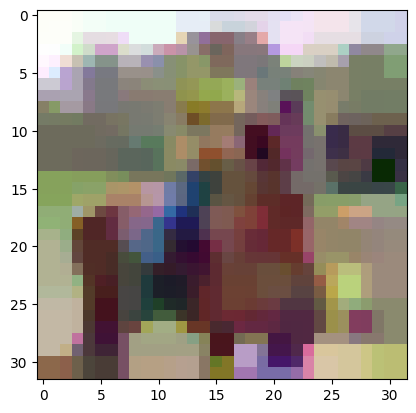

In [176]:
plot(output)

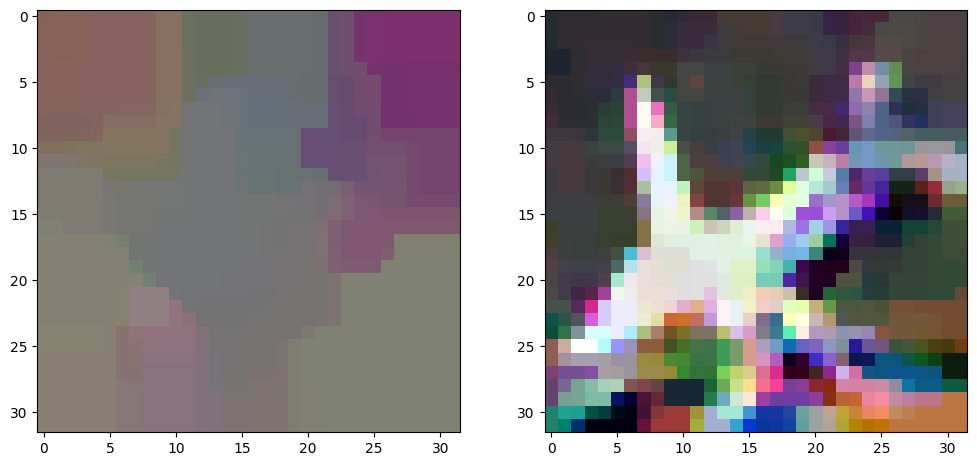

In [28]:
plot(output)

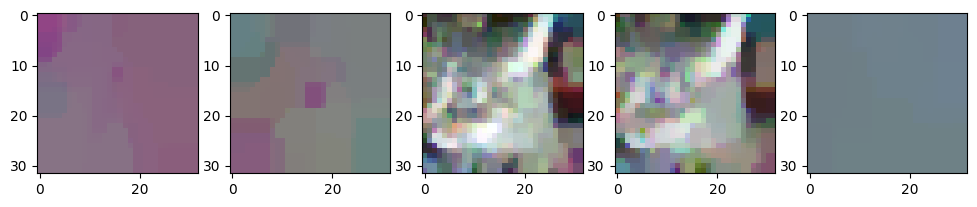

In [11]:
# lr 1
plot(output)

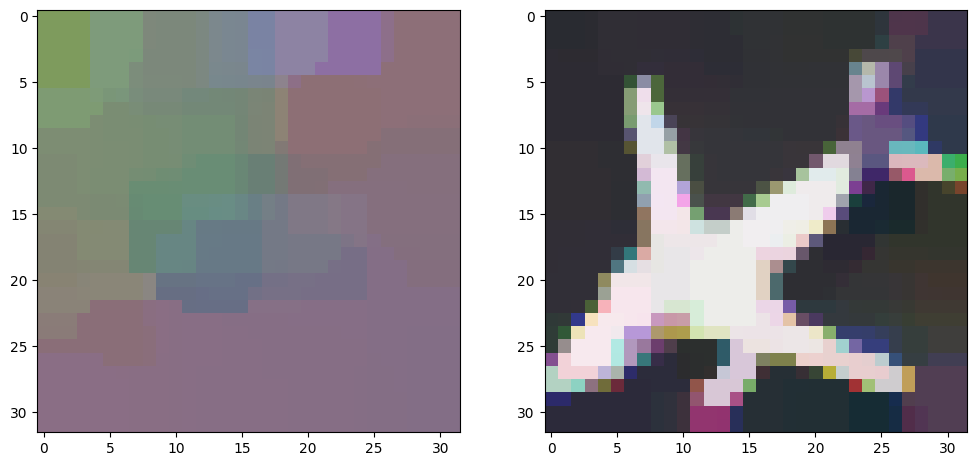

In [15]:
#lr 1
plot(output)